# 📘 Neural Network Basics (From Scratch, NumPy)
## 1. Imports and Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 2. Activation Functions

In [2]:
def sigmoid(x):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(output):
    """
    Derivative of sigmoid.
    Note: derivative is computed using the output of sigmoid
    """
    return output * (1 - output)

## 3. Loss Function

In [3]:
def mean_squared_error(y_true, y_pred):
    """Mean Squared Error (MSE) loss"""
    return np.mean((y_true - y_pred) ** 2)


## 4. Single-Layer Perceptron

In [4]:
class Perceptron:
    """
    Single-layer Perceptron for binary classification
    """

    def __init__(self, input_dim, learning_rate=0.1):
        self.lr = learning_rate
        self.weights = np.zeros(input_dim)
        self.bias = 0.0

    def predict(self, x):
        z = np.dot(x, self.weights) + self.bias
        return 1 if z >= 0 else 0

    def train(self, X, y, epochs=10):
        for _ in range(epochs):
            for xi, yi in zip(X, y):
                y_pred = self.predict(xi)
                error = yi - y_pred
                self.weights += self.lr * error * xi
                self.bias += self.lr * error


Example: AND Logic Gate

In [5]:
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])

perceptron = Perceptron(input_dim=2)
perceptron.train(X_and, y_and)

for x in X_and:
    print(x, "->", perceptron.predict(x))

[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


## 5. Multi-Layer Perceptron (MLP)

Architecture:
- Input layer
- One hidden layer
- Output layer
- Sigmoid activation
- Trained using Backpropagation

In [6]:
class MultiLayerPerceptron:
    """
    Simple Multi-Layer Perceptron (MLP)
    """

    def __init__(self, input_dim, hidden_dim, output_dim, learning_rate=0.1):
        self.lr = learning_rate

        # Weight initialization
        self.W1 = np.random.randn(input_dim, hidden_dim)
        self.b1 = np.zeros((1, hidden_dim))

        self.W2 = np.random.randn(hidden_dim, output_dim)
        self.b2 = np.zeros((1, output_dim))

        self.loss_history = []

    def forward(self, X):
        """
        Forward propagation
        """
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.output = sigmoid(self.z2)

        return self.output

    def backward(self, X, y):
        """
        Backpropagation
        """
        error_output = y - self.output
        delta_output = error_output * sigmoid_derivative(self.output)

        error_hidden = np.dot(delta_output, self.W2.T)
        delta_hidden = error_hidden * sigmoid_derivative(self.a1)

        # Update parameters
        self.W2 += self.lr * np.dot(self.a1.T, delta_output)
        self.b2 += self.lr * np.sum(delta_output, axis=0, keepdims=True)

        self.W1 += self.lr * np.dot(X.T, delta_hidden)
        self.b1 += self.lr * np.sum(delta_hidden, axis=0, keepdims=True)

    def train(self, X, y, epochs=1000):
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = mean_squared_error(y, y_pred)
            self.loss_history.append(loss)

            self.backward(X, y)

            if epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | Loss: {loss:.6f}")


## 6. Training on XOR Dataset

In [7]:
# XOR dataset
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_xor = np.array([
    [0],
    [1],
    [1],
    [0]
])

mlp = MultiLayerPerceptron(
    input_dim=2,
    hidden_dim=4,
    output_dim=1,
    learning_rate=0.5
)

mlp.train(X_xor, y_xor, epochs=2000)

Epoch    0 | Loss: 0.283190
Epoch  100 | Loss: 0.249257
Epoch  200 | Loss: 0.245271
Epoch  300 | Loss: 0.234821
Epoch  400 | Loss: 0.212744
Epoch  500 | Loss: 0.183589
Epoch  600 | Loss: 0.151090
Epoch  700 | Loss: 0.101992
Epoch  800 | Loss: 0.057959
Epoch  900 | Loss: 0.033460
Epoch 1000 | Loss: 0.021113
Epoch 1100 | Loss: 0.014551
Epoch 1200 | Loss: 0.010731
Epoch 1300 | Loss: 0.008318
Epoch 1400 | Loss: 0.006691
Epoch 1500 | Loss: 0.005537
Epoch 1600 | Loss: 0.004684
Epoch 1700 | Loss: 0.004034
Epoch 1800 | Loss: 0.003525
Epoch 1900 | Loss: 0.003117


## 7. Model Prediction

In [8]:
print("\nXOR Predictions:")
for x in X_xor:
    pred = mlp.forward(x.reshape(1, -1))
    print(x, "->", pred.round(3))


XOR Predictions:
[0 0] -> [[0.037]]
[0 1] -> [[0.949]]
[1 0] -> [[0.945]]
[1 1] -> [[0.064]]


## 8. Loss Curve Visualization

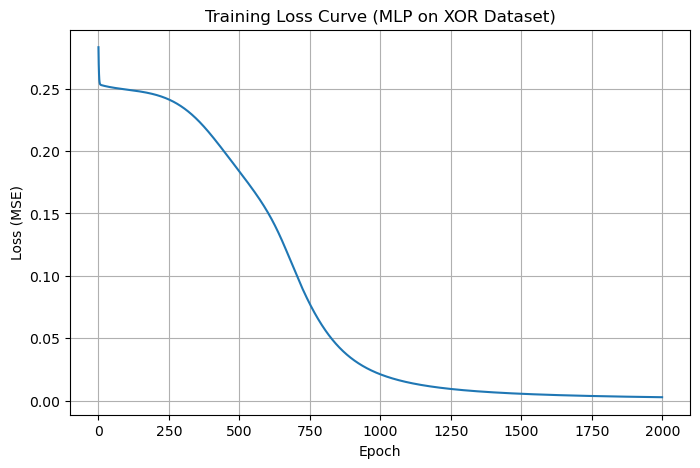

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss Curve (MLP on XOR Dataset)")
plt.grid(True)
plt.show()

## 9. Academic Summary (Ready for Report)

This notebook demonstrates:
- Perceptron learning for linearly separable problems
- Multi-Layer Perceptron (MLP) for non-linear problems
- Forward propagation using sigmoid activation
- Backpropagation using gradient descent
- Loss minimization using Mean Squared Error
- Visualization of training convergence